## Сессия 7 - Продвинутая визуализация, Корреляция 

### **Гипотеза:** Время доставки влияет на конечную оцену пользователя

#### Загрузим датафрейм, сформированный из всех таблиц исходного датасета. Произведем приведение типов данных в столбцах содержащих дату и время. 



In [34]:
import pandas as pd 

df_data = pd.read_csv('data_from_notes/full_data.csv', sep = ';')


cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date', 'review_creation_date', 'review_answer_timestamp']
for col in cols:
    df_data[col] = pd.to_datetime(df_data[col], format = 'mixed')

# Создадим колонку дней доставки, для дальнейшей работы
df_data['delivery_days'] = (df_data['order_delivered_customer_date'] - df_data['order_purchase_timestamp']).dt.days.astype('float32')

# Удалим технические флаги, которые не несут в себе полезной информации
df_data.drop(columns = ['is_delivered', 'confirm', 'conf_&_paid'], inplace = True)

# Создадим флаг, который поможет оставить только те заказы и строки, по которым доставка была действительно произведена, что соответствует цели исследования
df_data['delivered'] = df_data['delivery_days'].notna()

# Оставим только те заказы, доставка которых была произведена и посчитана ранее
df_data = df_data[df_data['delivered']]
df_data = df_data.drop(columns = ['delivered'])

# Отфильтруем данные по дате, так как начальные и конечные месяцы датафрейма имеют неполные данные о месяцах
start_date = '2017-01-01'
end_date = '2018-08-31'

date_mask = (df_data['order_purchase_timestamp'] >= start_date) & (df_data['order_purchase_timestamp'] <= end_date)
data = df_data[date_mask].copy()
# Посмотрим на полученный датафрейм кратко
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89808 entries, 0 to 92036
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       89808 non-null  object        
 1   customer_id                    89808 non-null  object        
 2   order_status                   89808 non-null  object        
 3   order_purchase_timestamp       89808 non-null  datetime64[ns]
 4   order_approved_at              89796 non-null  datetime64[ns]
 5   order_delivered_carrier_date   89807 non-null  datetime64[ns]
 6   order_delivered_customer_date  89808 non-null  datetime64[ns]
 7   order_estimated_delivery_date  89808 non-null  datetime64[ns]
 8   customer_unique_id             89808 non-null  object        
 9   customer_zip_code_prefix       89808 non-null  int64         
 10  customer_city                  89808 non-null  object        
 11  customer_state      

#### Перейдем к корреляционному анализу. Для того, чтобы мы могли провести его качественно и получить корректные данные. Для этого необходимо избавиться от выбросов, которые присутствуют в данных о времени доставки 

##### Выявим выбросы и отобразим их на ящике с усами. Выбросы будут выявляться при помощи метода IQR

Краткая сводка в текстовом представлении:
count    89808.000000
mean        11.950929
std          9.409304
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        208.000000
Name: delivery_days, dtype: float64


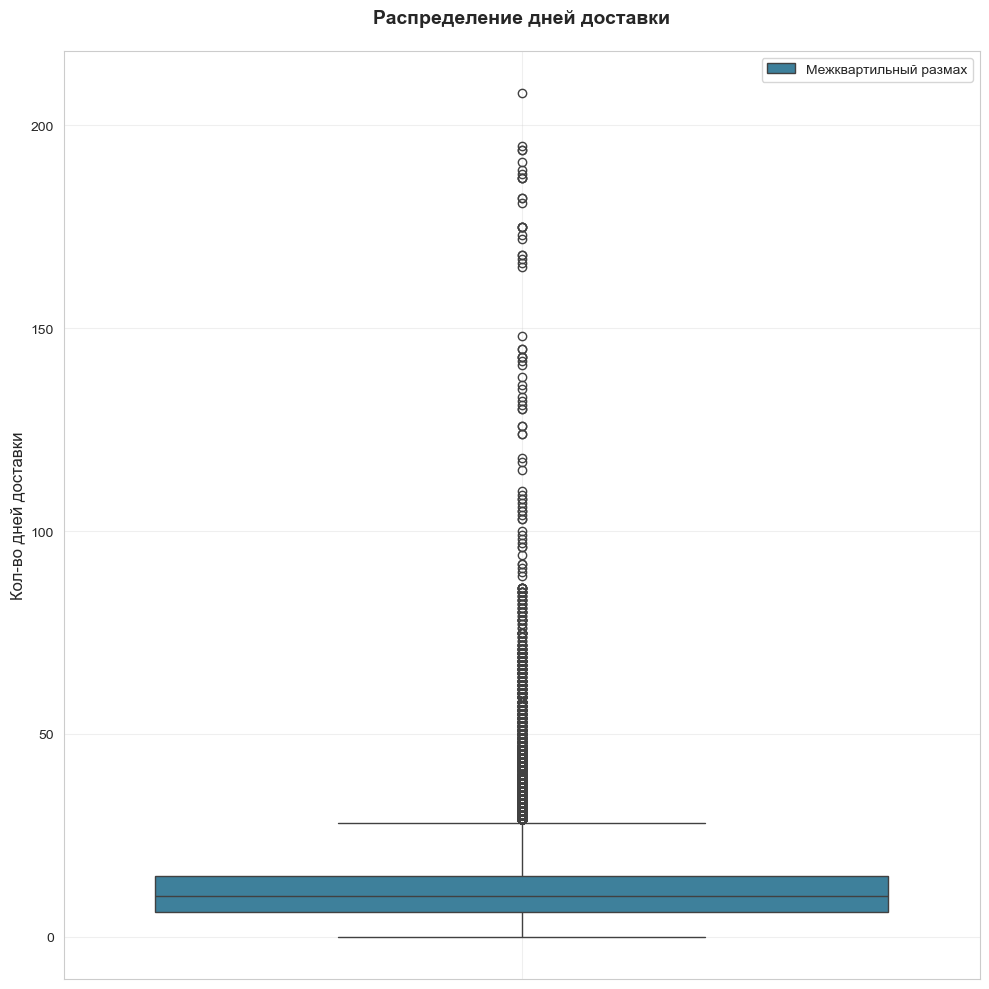

In [35]:
# Построим ящик с усами
import matplotlib.pyplot as plt
import seaborn as sns
# Применим кастомное оформление визуализаций
from style import setup_style, decorate

fig, ax = plt.subplots(figsize = (10, 10))
setup_style()

sns.boxplot(y = data['delivery_days'], ax = ax, label = 'Межквартильный размах')
decorate(ax, 'Распределение дней доставки', '', 'Кол-во дней доставки')
plt.tight_layout()
print(f"Краткая сводка в текстовом представлении:\n{data['delivery_days'].describe()}")


#### Как видно, в данных содержится значительное количество выбросов, что делает рассчет корреляции затруднительным, так как данные будут крайне сильно искажены. Для дальнейшего исследования необходимо очистить данные от выбросов при помощи IQR

In [36]:
# Произведем рассчет межквартиельного интервала
q1 = data['delivery_days'].quantile(0.25)
q3 = data['delivery_days'].quantile(0.75)

iqr = q3 - q1 
# Рассчитаем верхний и нижний ус для дальнейшего отсечения выбросов
lower_append = q1 - 1.5 * iqr
upper_append = q3 + 1.5 * iqr

# Создадим флаг, чтобы пометить заказы с выбросами
data['outlier_flag'] = (data['delivery_days'] < lower_append) | (data['delivery_days'] > upper_append)
print(f"Количество заказов (доставок) с выбросами: {data['outlier_flag'].sum()}")


Количество заказов (доставок) с выбросами: 4365


**Примечение: Мы получили 4420 заказов, содержащих выбросы (~5%). Исходя из прошлых этапов исследования известно, что природа выбросов не связана с ошибками данных, а являются реальными критическими задержками в доставке. Ранее, датасет, содержащий только выбросы был сохранен. Полученные выбросы будут удалены с целью получения корректных данных при дальнейшем рассчете**

Краткая сводка в текстовом представлении:
count    89808.000000
mean        11.950929
std          9.409304
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        208.000000
Name: delivery_days, dtype: float64


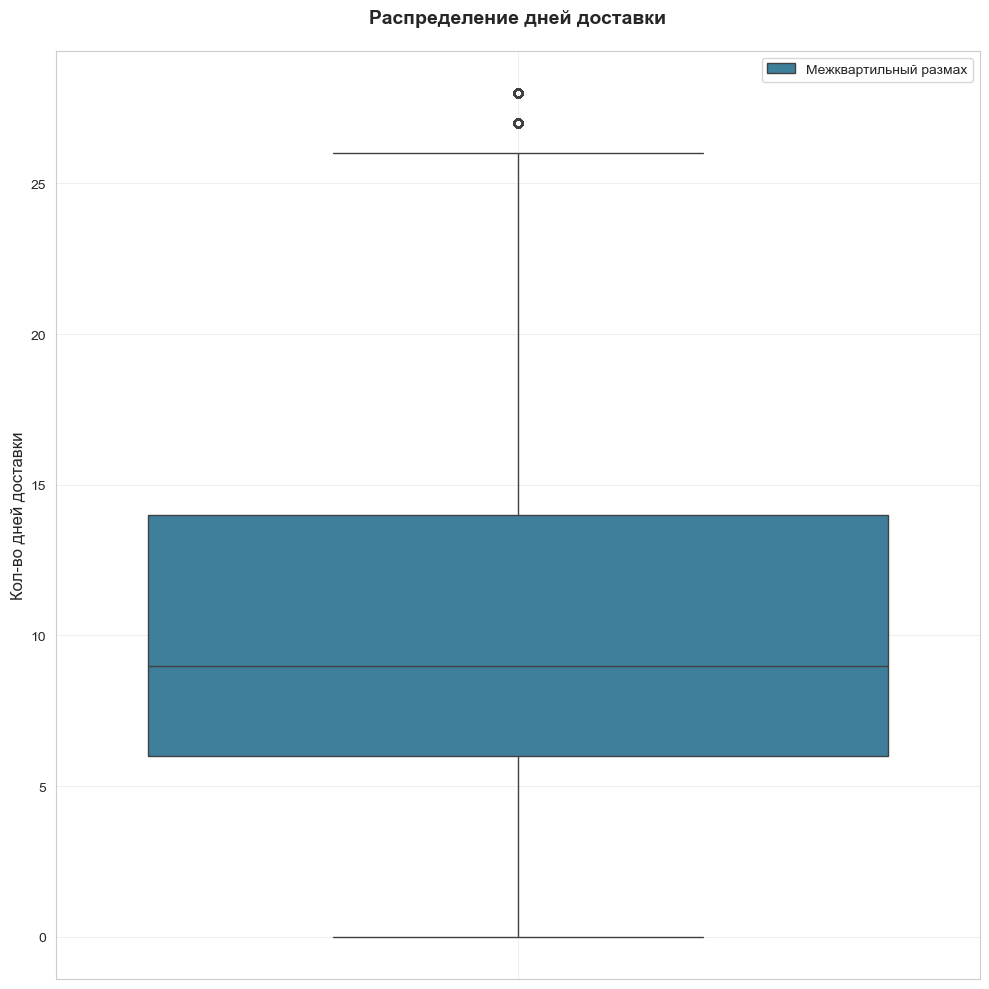

In [37]:
# Сформируем новый датафрейм, не содержащий выбросы
outlier_free_data = data[~data['outlier_flag']]
outlier_free_data = outlier_free_data.drop(columns = ['outlier_flag']).copy()
# Создадим ящик с усами и сравним его с полученным ранее.
fig, ax = plt.subplots(figsize = (10, 10))
setup_style()

sns.boxplot(y = outlier_free_data['delivery_days'], ax = ax, label = 'Межквартильный размах')
decorate(ax, 'Распределение дней доставки', '', 'Кол-во дней доставки')
plt.tight_layout()
print(f"Краткая сводка в текстовом представлении:\n{data['delivery_days'].describe()}")

#### Как видно, диаграмма показывает более спокойные данные, фиксируя крайне малое количество незначительных выбросов, которые не смогут значительно повлиять на дальнейшие рассчет. Так как при проведении анализа нашей целью, также является сохранение наибольшего количества данных, то дальнейшее удаление малозначительных выбросов не имеет смысла. **Итог: выбросы очищены, можно плавно переходить к корреляционному анализу**

* **Первичный вопрос: Выяснить, влияет ли время доставки на конечную оценку пользователя**
* **Вторичный вопрос: Влияет стоимость заказа на скорость доставки, влияет ли стоимость доставки на её скорость**

c:\Users\User\Analytics-Training\sprint2_olist\work_with_pandas\style.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


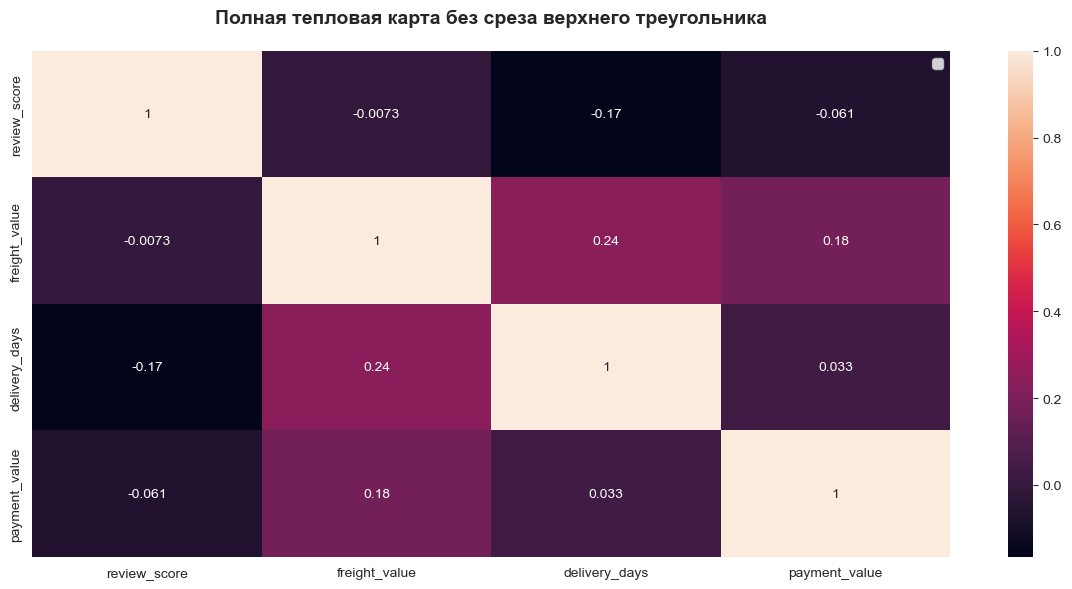

In [ ]:
from style import setup_style, decorate
import numpy as np
# Для ответа на интересующие вопросы необходимо взять из оснвного датафрейма необходмые столбцы и сгруппировать их для вычисления общей суммы каждого заказа.
cols_needed = ['order_id', 'customer_unique_id', 'payment_value', 'review_score', 'freight_value', 'delivery_days']
for_cor_data = outlier_free_data[cols_needed].copy()
grouped_data = for_cor_data.groupby(['order_id', 'customer_unique_id', 'review_score', 'freight_value', 'delivery_days'])['payment_value'].sum().reset_index()

# Для рассчета корреляции уберем из полученного датафрейма все текстовые столбцы.
cols = ['review_score', 'freight_value', 'delivery_days', 'payment_value']
corr_data = grouped_data[cols].copy()

#Построим тепловую карту для первичного выявления взаимосвязей между интересующими значениям.
corr_matrix = corr_data.corr()

setup_style()
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, ax=ax)
decorate(ax, 'Корреляция между значениями', '', '')
plt.tight_layout()


#### Не делая выводом можем заметить, что вся тепловая карта характеризуется достаточно слабыми корреляциями. Максмимальное значение - 0.24. Матрица коэфицентов корреляции была посчитана по методу Пирсона. Можно предположить, что данный способ рассчетов мог увидеть нелинейность, которая вполне вероятно присутствует между этими значениями. Для проверки этого предположения рассчитаем корреляционную матрицу по методу Спирмена и построим тепловую карту, после чего сможем сравнить полученный результат

c:\Users\User\Analytics-Training\sprint2_olist\work_with_pandas\style.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


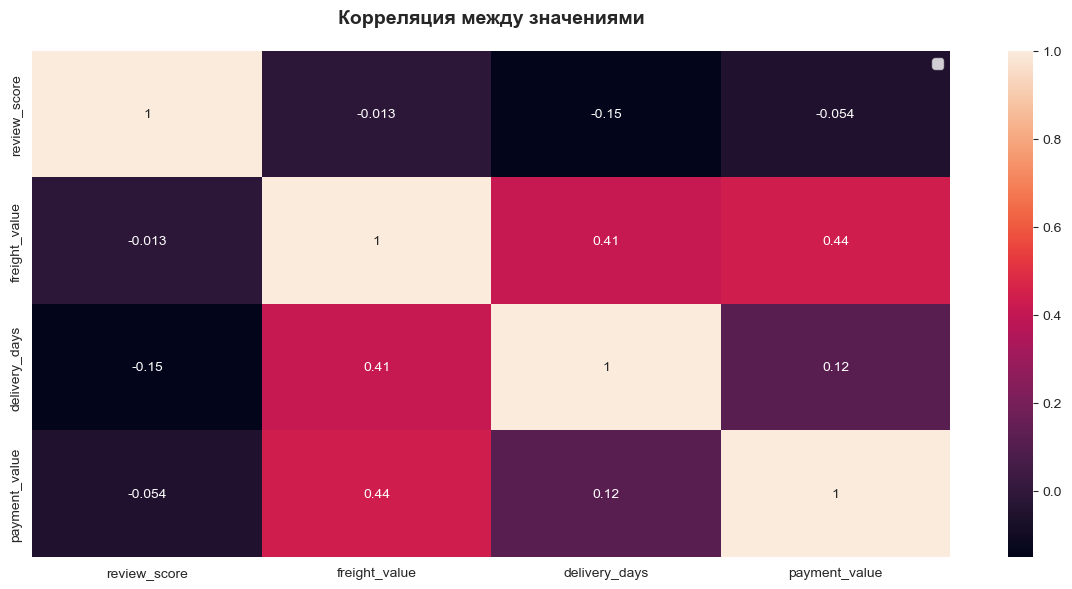

In [54]:
corr_matrix = corr_data.corr(method = 'spearman')

setup_style()
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, ax=ax)
decorate(ax, 'Корреляция между значениями', '', '')
plt.tight_layout()

#### После построения тепловых карт, основанных на корреляционных матрицах, построенных по методу Спирмана и Пирсона можно сделать предварительные выводы
##### **Метод Пирсона действительно исказил некоторые коэфиценты. Так, метод Пирсона значительно занизил коэффициент корреляции (КК) у payment_value <-> delivery_days, delivery_days <-> freight_value, что говорит о нелийной связи между этими значениями, которые были плохо перехвачены с помощью метода Пирсона**
##### Инсайты по полученным данным:
* **После рассчета двумя методами можно сказать, что наша главная гипотеза, предварительно, не подтвердилась и связь между сроком доставки и оценкой пользователя почти не наблюдается. Требуется дальнейшее исследование.**
* **Неожиданно, уверенная корреляция наблюдается между стоимостью доставки и cроком доставки, а также между стоимостью заказа и ** 